In [1]:
from scipy.fft import dct
import scipy.fftpack as fftpack
import yt
import numpy as np
from matplotlib import pyplot as plt
from field_kit import FourierAnalysis, GaussianRandomField, PowerLawBetaModel
from scipy.integrate import quad

In [2]:
def autocorr_fft(x):
    N = len(x)
    X = np.fft.fft(x, n=2*N)
    result = np.fft.ifft(X * np.conj(X)).real
    
    return result[:N]

def get_autocorr_fft(dx, y):
    return dx * autocorr_fft(y)
    ## Multiplying by dx approximates the continuous integral, previously, the autocorrelation function was unitless

def performCosineTransform(data):
    transform = fftpack.dct(data, type = 1) / 2  ##Scipy definition has additional factor of 2
    return transform

In [3]:
def calcProb(bx,by,dx, g_ay, m_a, polarisation = "both"):
    
    ###Convert to natural units
    dxNat = dx * 1.56e26

    bx_eV = bx * 1.95e-2 * 1e-6
    by_eV = by * 1.95e-2 * 1e-6 

    ###Determine autocorrelation function
    acf_bx = get_autocorr_fft(dxNat, bx_eV)
    acf_by = get_autocorr_fft(dxNat, bx_eV)

    ###Determine cosine transform
    cosTransX = performCosineTransform(acf_bx) * dxNat
    cosTransY = performCosineTransform(acf_by) * dxNat

    Px = (g_ay ** 2) * cosTransX / 2
    Py = (g_ay ** 2) * cosTransY / 2

    if polarisation == "both":
        P = (Px + Py) / 2
    elif polarisation == "x":
        P = Px
    elif polarisation == "y":
        P = Py
    else:
        print("Unknown polarisation state.")
    
    
    N = bx_eV.size
    L = N * dxNat
    
    kx = np.pi * np.arange(0, N, 1) / L
    
    with np.errstate(divide='ignore'):
        E = (m_a ** 2) / (2 * kx)

    return E,P

In [4]:
def genGRFBox(length, seed, ddim, l_min = 1.0, l_max = 200.0, alpha = -11.0 / 3.0, f_rms = 10.0, div = False):
   
    # Make a power-law spectrum
    power_spec = PowerLawBetaModel(l_min, l_max, alpha)
    
    # Renomalize the power spectrum to have the desired RMS value
    power_spec.renormalize(f_rms)
    
    # Parameters for the box and grid
    le = np.array([0.0, 0.0, 0.0])
    re = np.array([length, length, length])
    ddims = [ddim] * 3
    width = re - le

    dx = (re[2] - le[2]) / ddims[2]
    
    vgen = GaussianRandomField(le, re, ddims, power_spec, seed=seed)
    v = vgen.generate_vector_field_realization()

    fa = FourierAnalysis(re, ddims)
    
    if div == False:
        print("Removing Divergence")
        # For a certain condition, v = vc + vs, which is satisified here 
        vc = fa.divergence_component(v)
        vs = v-vc

        v = vs

    return v,dx,fa

In [5]:
def makePk3D(bx,by,bz,fa,window = False):

    nbins = 64

    ###The MHD simulation should be windowed to prevent leakage whereas the GRF should not
    if window == True:
        fa.window_data(bx, filter_function="tukey")
        fa.window_data(by, filter_function="tukey")
        fa.window_data(bz, filter_function="tukey")
    
    k_bins, Pkx = fa.make_binned_powerspec(bx, nbins)
    _, Pky = fa.make_binned_powerspec(by, nbins)
    _, Pkz = fa.make_binned_powerspec(bz, nbins)

    #Determines the power spectrum as a linear combination of components, division by 4pi is for conversion from CGS units
    Pk = (Pkx + Pky + Pkz) / (4 * np.pi) 
    k = np.sqrt(k_bins[1:] * k_bins[:-1])
    k = k[~Pk.mask]
    Pk = Pk[~Pk.mask]
    
    return Pk, k

In [6]:
def makePk1D(Pk3D, k, eta, analytical = False, l_min = 1.0, l_max = 200.0, alpha = -11.0/3.0):
    
    from scipy.interpolate import interp1d

    if analytical:
    ###Creates an analytical kolmogorov spectrum with the same dissipation and injection scale as our created GRF. Can be adjusted.
        f_rms = 10.0

        power_spec = PowerLawBetaModel(l_min, l_max, alpha)
    
        # Renomalize the power spectrum to have the desired RMS value
        power_spec.renormalize(f_rms)

        interp_P3D = lambda k: 3.0*(2/3)*power_spec(k)/(4.0*np.pi)  ##3 from 3 components of the field, 2/3 comes from the divergence free field, 4pi natural units

    else:
    ###Creates an interpolation function to match Equation 10 of Carenza et al 2024.
        interp_P3D = interp1d(
            k,
            Pk3D,
            kind="cubic",
            bounds_error=False,       
            fill_value="extrapolate"           
        )

        

    ###Follows Equation 10 Carenza et al 2024.
    
    """
    term1 = k / (2 * (2 * np.pi)**3)

    kprime = np.sqrt(eta**2 + k**2)
    term2 = interp_P3D(kprime)

    term3 = 1 - 0.5 * (k**2 / (eta**2 + k**2))

    integrand = term1 * term2 * term3
    """

    def integrand_func(k):
        term1 = k / (2 * (2 * np.pi)**3)
        kprime = np.sqrt(eta**2 + k**2)
        term2 = interp_P3D(kprime)
        term3 = 1 - 0.5 * (k**2 / (eta**2 + k**2))
        return term1 * term2 * term3

    Pk1D = quad(integrand_func, 0.0, 100.0)[0]  # Numerical integration using quad
    Pk1D = Pk1D * 2.304e56 * (4.018e-35)**2  #GeV**3 Conversion factor

    return Pk1D

In [7]:
length = 750.0

In [8]:
#v, dx, fa = genGRFBox(length, seed = 100, ddim = 256, div = False) # Remove Divergence
v, dx, fa = genGRFBox(length, seed = 100, ddim = 256, div = False)

bx = v[0,:,:,:]
by = v[1,:,:,:]
bz = v[2,:,:,:]
print(bx.shape)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Removing Divergence
(256, 256, 256)


In [9]:
Nx, Ny, Nz = bx.shape

g_ay = 1e-12 * 1e-9 
m_a = 1e-10

#P_total = np.zeros(256)
P_total = np.zeros(256)

xy = [(i, j) for i in range(Nx) for j in range(Ny)]
samples = 256**2  ##Number of rays tested (adjust for speed)


for idx, (i, j) in enumerate(xy[:samples]):

    bx_line = bx[i, j, :]
    by_line = by[i, j, :]

    E,P = calcProb(bx_line,by_line,dx,g_ay,m_a)

    P_total += P

g_ay *= 1e9

P_mean = P_total / samples
B_square_mean = (P_mean * 4) / (g_ay ** 2)

etas = 0.078 * (m_a**2 / (1e-12)**2) * ( 1 / E)

In [10]:
Pk3D,k = makePk3D(bx,by,bz,fa, window = False)

Pk1Ds = np.zeros(len(etas))
Pk1DsAnalytical = np.zeros(len(etas))

for i, eta in enumerate(etas):
    Pk1Ds[i] = makePk1D(Pk3D,k,eta)
    Pk1DsAnalytical[i] = makePk1D(Pk3D,k,eta, analytical = True)

###Determine B^2 from the analytical GRF method

kpc_to_cm = 3.0857e21
cm_to_GeV_inv = 50676.79373667135 * 1e9

length_ev = length * kpc_to_cm * cm_to_GeV_inv  # GeV^-1

BSquareGRF = Pk1Ds * (length_ev / (2*np.pi)) # GeV^-2
BSquareGRFa = Pk1DsAnalytical * (length_ev / (2*np.pi)) # GeV^-2

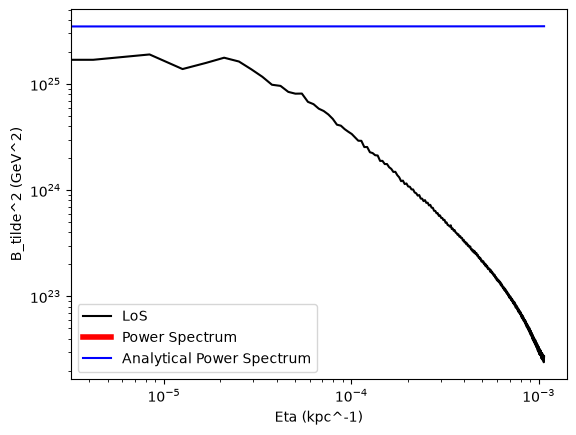

In [11]:
plt.plot(etas, B_square_mean, color = "black", label = "LoS")
plt.plot(etas, BSquareGRF, color = "red", label = "Power Spectrum", lw=4)
plt.plot(etas, BSquareGRFa, color = "blue", label = "Analytical Power Spectrum")
plt.yscale("log")
plt.xscale("log")

plt.xlabel("Eta (kpc^-1)")
plt.ylabel("B_tilde^2 (GeV^2)")

plt.legend()

In [12]:
BSquareGRF

array([-9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -9.15950807e+33, -9.15950807e+33, -9.15950807e+33,
       -9.15950807e+33, -